In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install imbalanced-learn and xgboost
!pip install -q imbalanced-learn xgboost

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
# Load Data
file_path = '/content/drive/MyDrive/GSE65683_ClusterData_PercRank_GEOsubmission.xlsx'
df = pd.read_excel(file_path)

In [ ]:
# Prepare Data
metadata_cols = ['chr', 'start', 'end', 'Element name', 'strand']
expression_df = df.drop(columns=metadata_cols).T
expression_df.columns = df['Element name']
expression_df.index.name = 'SampleID'

In [ ]:
print(expression_df.head())



Element name  uc001aaa.3_1  uc001aaa.3_2  uc001aaa.3_3  uc010nxr.1_2  \
SampleID                                                               
S25               0.000000      0.000000      0.740841      0.000000   
S52               0.487285      0.583267      0.566300      0.662522   
S3                0.000000      0.000000      0.759215      0.000000   
S17               0.000000      0.000000      0.602943      0.000000   
S13               0.000000      0.000000      0.764574      0.000000   

Element name  uc010nxq.1_2  uc010nxq.1_3  uc009vis.3_1  uc009vis.3_2  \
SampleID                                                               
S25               0.000000      0.741261      0.776422      0.924262   
S52               0.569954      0.534355      0.662633      0.000000   
S3                0.000000      0.747022      0.773439      0.807588   
S17               0.000000      0.603726      0.656187      0.674126   
S13               0.000000      0.773238      0.744405      0.8

In [ ]:
print("Shape:", expression_df.shape)
print("Column names (first 5):", expression_df.columns[:5].tolist())
print("Index (Sample IDs):", expression_df.index[:5].tolist())


Shape: (72, 278605)
Column names (first 5): ['uc001aaa.3_1', 'uc001aaa.3_2', 'uc001aaa.3_3', 'uc010nxr.1_2', 'uc010nxq.1_2']
Index (Sample IDs): ['S25', 'S52', 'S3', 'S17', 'S13']


In [ ]:
# Label Mapping
group_labels = {
    **{f'S{i}': 0 for i in range(1, 8)},       # Natural conception LB
    **{f'S{i}': 1 for i in range(8, 37)},      # IUI or TIC
    **{f'S{i}': 2 for i in range(37, 51)},     # Failed IUI → ART
    **{f'S{i}': 3 for i in range(51, 64)},     # Voluntary ART
    **{f'H{i}': 4 for i in range(1, 6)},       # External clinic LB
    **{f'S{i}': 5 for i in range(64, 68)},     # Suspected female factor
}
expression_df['Label'] = expression_df.index.map(group_labels)
expression_df = expression_df.dropna(subset=['Label'])

<ipython-input-8-514ba086ded0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=expression_df, palette='viridis')


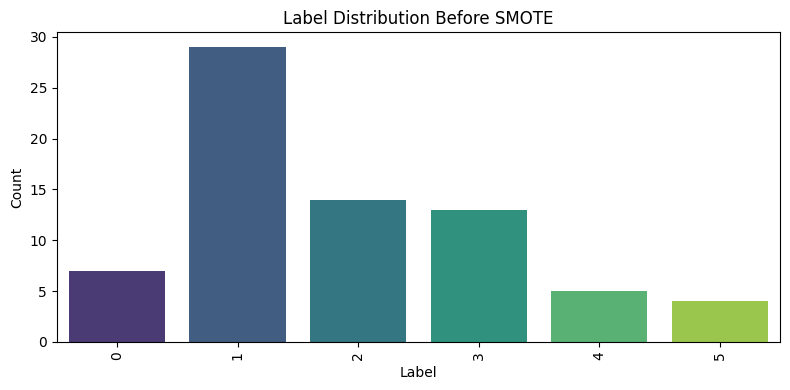


 Label Descriptions:
Label 0: I: Natural conception LB
Label 1: II-i: IUI/TIC Success
Label 2: II-ii: Failed IUI → ART
Label 3: II-iii: Voluntary ART
Label 4: III-i: External clinic LB
Label 5: III-ii: Suspected female factor


In [ ]:
# EDA Before SMOTE
plt.figure(figsize=(8, 4))
sns.countplot(x='Label', data=expression_df, palette='viridis')
plt.xticks(rotation=90)
plt.title("Label Distribution Before SMOTE")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

label_map = {
    0: "I: Natural conception LB",
    1: "II-i: IUI/TIC Success",
    2: "II-ii: Failed IUI → ART",
    3: "II-iii: Voluntary ART",
    4: "III-i: External clinic LB",
    5: "III-ii: Suspected female factor"
}
print("\n Label Descriptions:")
for k, v in label_map.items():
    print(f"Label {k}: {v}")

In [ ]:
# Preprocessing
X = expression_df.drop(columns='Label')
y = expression_df['Label'].astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Convert scaled NumPy array back to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Display top 5 rows
print(X_scaled_df.head())


Element name  uc001aaa.3_1  uc001aaa.3_2  uc001aaa.3_3  uc010nxr.1_2  \
SampleID                                                               
S25              -0.696706     -0.464516      0.839062     -0.374367   
S52               0.859879      1.614790      0.233491      2.272619   
S3               -0.696706     -0.464516      0.902810     -0.374367   
S17              -0.696706     -0.464516      0.360624     -0.374367   
S13              -0.696706     -0.464516      0.921404     -0.374367   

Element name  uc010nxq.1_2  uc010nxq.1_3  uc009vis.3_1  uc009vis.3_2  \
SampleID                                                               
S25              -0.464180      0.863645      0.470526      1.688403   
S52               1.599628      0.156311     -0.102470     -0.764753   
S3               -0.464180      0.883339      0.455504      1.378730   
S17              -0.464180      0.393464     -0.134929      1.024498   
S13              -0.464180      0.972962      0.309301      1.5

In [ ]:
X_orig = X.copy()
y_orig = y.copy()


In [ ]:
# SMOTE
min_class_size = min(y.value_counts().values)
k_neighbors = min_class_size - 1 if min_class_size > 1 else 1
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

<ipython-input-13-d938bded3531>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='plasma')


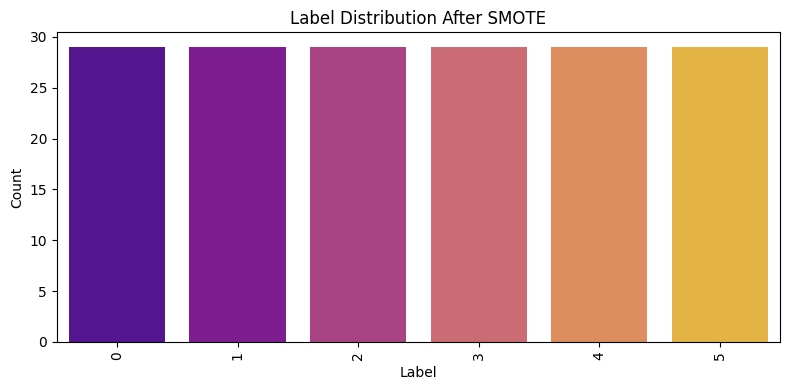

In [ ]:
# EDA After SMOTE
plt.figure(figsize=(8, 4))
sns.countplot(x=y_resampled, palette='plasma')
plt.xticks(rotation=90)
plt.title("Label Distribution After SMOTE")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Class Weights
classes = np.unique(y_resampled)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_resampled)
class_weights = dict(zip(classes, weights))

# Helper: Confusion Matrix Heatmap
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False, square=True)
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# Helper: Top Genes Plot
def top_genes(model, model_name):
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[::-1][:20]
    top_genes = X.columns[top_indices]
    plt.figure(figsize=(10, 5))
    plt.barh(top_genes[::-1], importances[top_indices][::-1], color='teal')
    plt.title(f"Top 20 Genes - {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(f"Top 20 Genes for {model_name}:")
    for i, gene in enumerate(top_genes):
        print(f"{i+1}. {gene} ({importances[top_indices[i]]:.4f})")



Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      0.83      0.91         6
           2       0.86      1.00      0.92         6
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         6

    accuracy                           0.97        35
   macro avg       0.98      0.97      0.97        35
weighted avg       0.98      0.97      0.97        35



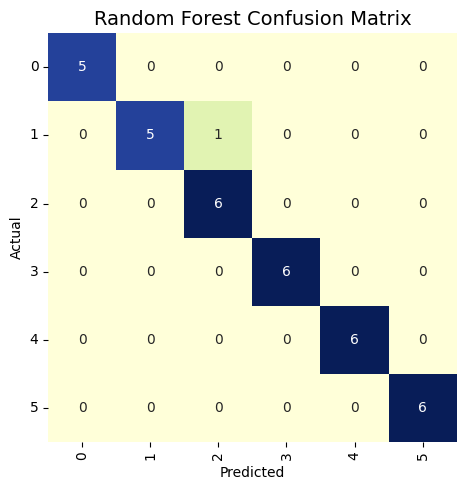

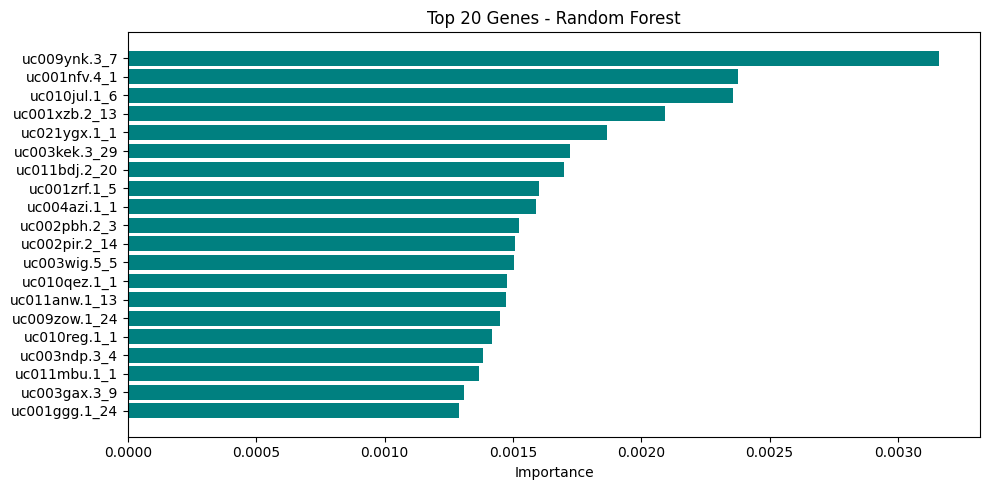

Top 20 Genes for Random Forest:
1. uc009ynk.3_7 (0.0032)
2. uc001nfv.4_1 (0.0024)
3. uc010jul.1_6 (0.0024)
4. uc001xzb.2_13 (0.0021)
5. uc021ygx.1_1 (0.0019)
6. uc003kek.3_29 (0.0017)
7. uc011bdj.2_20 (0.0017)
8. uc001zrf.1_5 (0.0016)
9. uc004azi.1_1 (0.0016)
10. uc002pbh.2_3 (0.0015)
11. uc002pir.2_14 (0.0015)
12. uc003wig.5_5 (0.0015)
13. uc010qez.1_1 (0.0015)
14. uc011anw.1_13 (0.0015)
15. uc009zow.1_24 (0.0015)
16. uc010reg.1_1 (0.0014)
17. uc003ndp.3_4 (0.0014)
18. uc011mbu.1_1 (0.0014)
19. uc003gax.3_9 (0.0013)
20. uc001ggg.1_24 (0.0013)


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight=class_weights, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
top_genes(rf, "Random Forest")

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

# Prepare One-vs-Rest setup
unique_classes = np.sort(y_resampled.unique())
class_top_genes = {}

# Loop through each class (e.g., 0, 1, 2, 3)
for class_label in unique_classes:
    print(f"\n=== One-vs-Rest for Class {class_label} ===")

    # Binarize label: current class vs rest
    y_binary = (y_resampled == class_label).astype(int)

    # Train Random Forest on binary target
    clf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(X_resampled, y_binary)

    # Extract top 20 genes based on importance
    importances = clf.feature_importances_
    top_indices = np.argsort(importances)[::-1][:20]
    top_genes = X.columns[top_indices]
    top_importances = importances[top_indices]

    # Log2 Fold Change: compare class vs rest
    group_class = X_orig[y_orig == class_label]
    group_others = X_orig[y_orig != class_label]

    updown_info = []
    for gene in top_genes:
        mean_class = group_class[gene].mean() + 1e-9
        mean_rest = group_others[gene].mean() + 1e-9
        log2fc = np.log2(mean_class / mean_rest)
        status = "Upregulated" if log2fc > 0 else "Downregulated"
        updown_info.append((gene, log2fc, status))

    # Save to DataFrame
    class_top_df = pd.DataFrame(updown_info, columns=["Gene", f"Log2FC(Class {class_label})", "Status"])
    class_top_df["Importance"] = top_importances
    class_top_df = class_top_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

    # Display
    print(class_top_df)

    # Save results per class
    class_top_genes[class_label] = class_top_df





Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      0.83      0.91         6
           2       0.86      1.00      0.92         6
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         6

    accuracy                           0.97        35
   macro avg       0.98      0.97      0.97        35
weighted avg       0.98      0.97      0.97        35



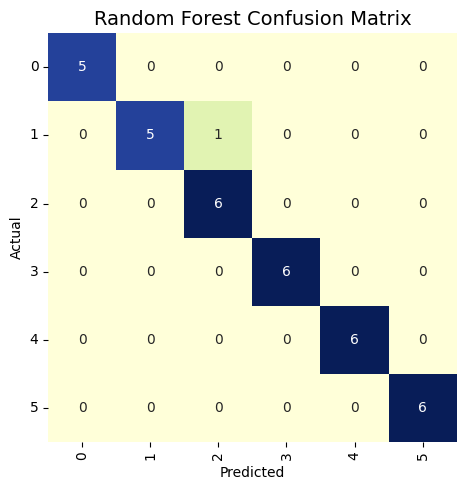

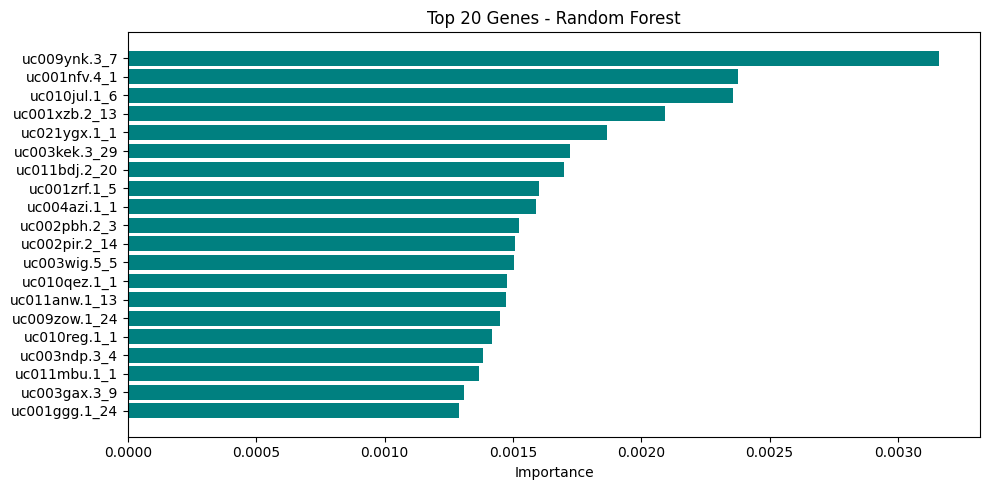

Top 20 Genes for Random Forest:
1. uc009ynk.3_7 (0.0032)
2. uc001nfv.4_1 (0.0024)
3. uc010jul.1_6 (0.0024)
4. uc001xzb.2_13 (0.0021)
5. uc021ygx.1_1 (0.0019)
6. uc003kek.3_29 (0.0017)
7. uc011bdj.2_20 (0.0017)
8. uc001zrf.1_5 (0.0016)
9. uc004azi.1_1 (0.0016)
10. uc002pbh.2_3 (0.0015)
11. uc002pir.2_14 (0.0015)
12. uc003wig.5_5 (0.0015)
13. uc010qez.1_1 (0.0015)
14. uc011anw.1_13 (0.0015)
15. uc009zow.1_24 (0.0015)
16. uc010reg.1_1 (0.0014)
17. uc003ndp.3_4 (0.0014)
18. uc011mbu.1_1 (0.0014)
19. uc003gax.3_9 (0.0013)
20. uc001ggg.1_24 (0.0013)
             Gene  Log2FC(Group0 vs Others)         Status
12   uc010qez.1_1                  3.183631    Upregulated
16   uc003ndp.3_4                  2.737608    Upregulated
11   uc003wig.5_5                  1.569499    Upregulated
2    uc010jul.1_6                  0.402986    Upregulated
8    uc004azi.1_1                  0.325855    Upregulated
14  uc009zow.1_24                  0.057589    Upregulated
15   uc010reg.1_1                  0.

In [ ]:
# Helper: Top Genes Plot
def top_genes(model, model_name, X_data): # Add X_data as an argument to access column names
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[::-1][:20]
    # Get the gene names from the DataFrame columns using the indices
    top_gene_names = X_data.columns[top_indices]
    plt.figure(figsize=(10, 5))
    plt.barh(top_gene_names[::-1], importances[top_indices][::-1], color='teal')
    plt.title(f"Top 20 Genes - {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(f"Top 20 Genes for {model_name}:")
    for i, gene in enumerate(top_gene_names):
        print(f"{i+1}. {gene} ({importances[top_indices[i]]:.4f})")

    # Return the list of top gene names
    return top_gene_names.tolist()

# Random Forest (Modify the call to top_genes)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight=class_weights, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")

# Call top_genes and capture the returned list of gene names
top_gene_ids = top_genes(rf, "Random Forest", X) # Pass the original X data to get gene names

# Top genes already extracted in `top_gene_ids` list (Now this variable is defined)

group_0 = X_orig[y_orig == 0]
others = X_orig[y_orig != 0]

updown_status = []

for gene in top_gene_ids:
    # Add a small constant to avoid log2(0) issues if mean is 0
    mean_group0 = group_0[gene].mean() + 1e-9
    mean_others = others[gene].mean() + 1e-9
    log2_fc = np.log2(mean_group0) - np.log2(mean_others)

    status = "Upregulated" if log2_fc > 0 else "Downregulated"
    updown_status.append((gene, log2_fc, status))

status_df = pd.DataFrame(updown_status, columns=["Gene", "Log2FC(Group0 vs Others)", "Status"])
print(status_df.sort_values(by='Log2FC(Group0 vs Others)', ascending=False))

In [ ]:
# Load the annotation TSV file
annot_path = "/content/drive/MyDrive/Human.GRCh38.p13.annot.tsv.gz"  # adjust path if needed
annot_df = pd.read_csv(annot_path, sep='\t')

# Preview the file
print("Annotation file loaded. Columns:")
print(annot_df.columns.tolist())
print("\nSample rows:")
print(annot_df.head())


Annotation file loaded. Columns:
['GeneID', 'Symbol', 'Description', 'Synonyms', 'GeneType', 'EnsemblGeneID', 'Status', 'ChrAcc', 'ChrStart', 'ChrStop', 'Orientation', 'Length', 'GOFunctionID', 'GOProcessID', 'GOComponentID', 'GOFunction', 'GOProcess', 'GOComponent']

Sample rows:
      GeneID       Symbol                                 Description  \
0  100287102      DDX11L1  DEAD/H-box helicase 11 like 1 (pseudogene)   
1     653635       WASH7P           WASP family homolog 7, pseudogene   
2  102466751    MIR6859-1                             microRNA 6859-1   
3  107985730  MIR1302-2HG                         MIR1302-2 host gene   
4  100302278    MIR1302-2                             microRNA 1302-2   

                    Synonyms GeneType    EnsemblGeneID  Status        ChrAcc  \
0                        NaN   pseudo  ENSG00000290825  active  NC_000001.11   
1              FAM39F|WASH5P   pseudo              NaN  active  NC_000001.11   
2             hsa-mir-6859-1    ncRNA  

<ipython-input-28-cdedc63fd166>:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  annot_df = pd.read_csv(annot_path, sep='\t')


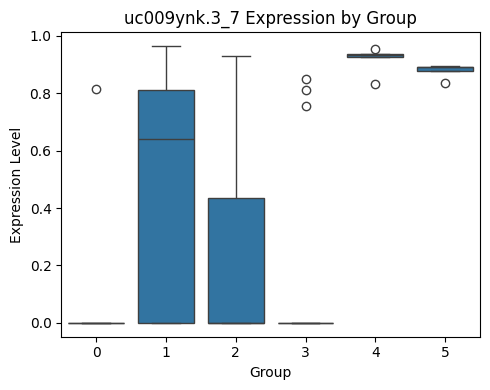

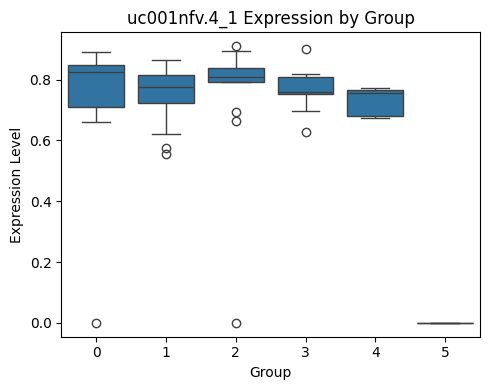

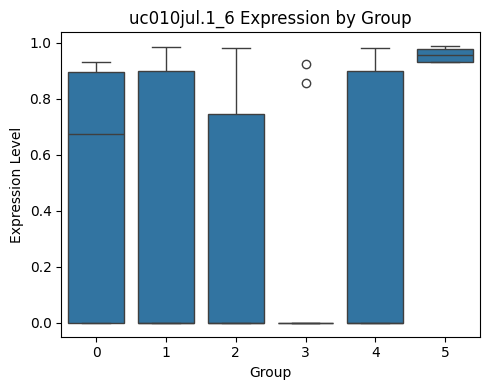

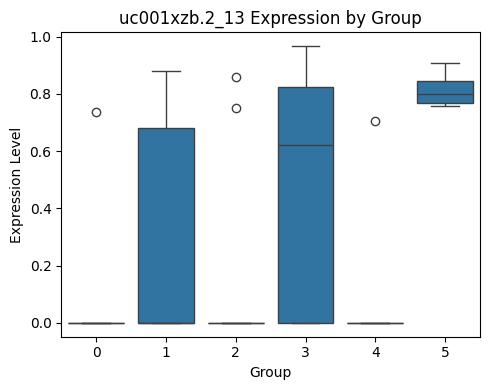

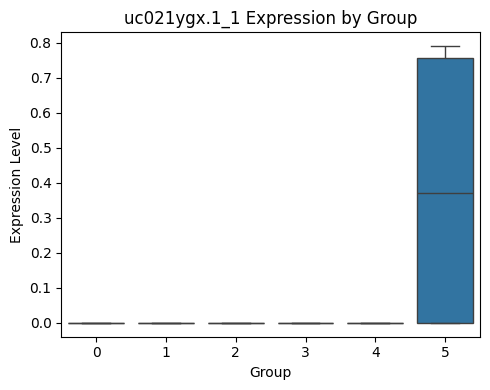

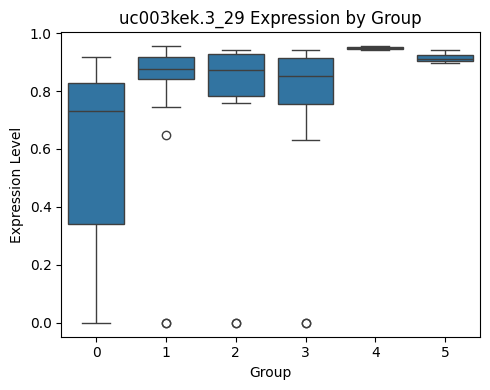

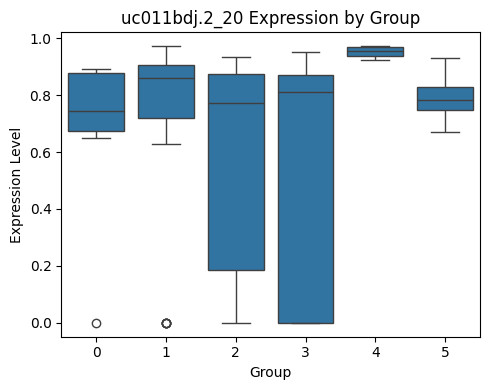

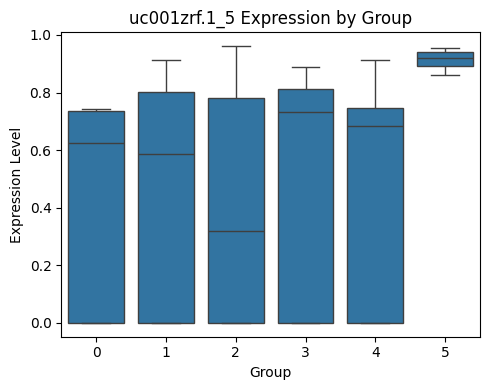

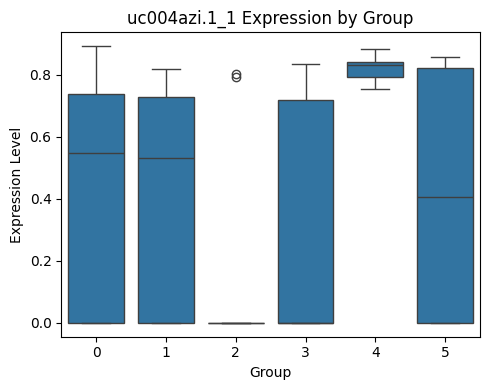

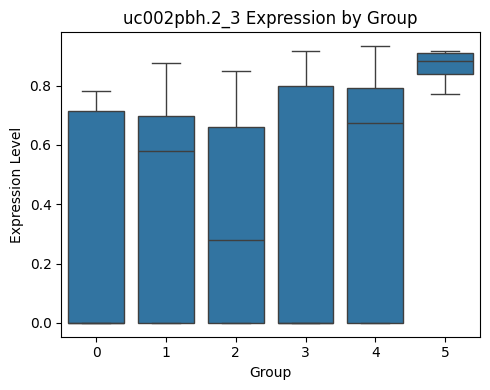

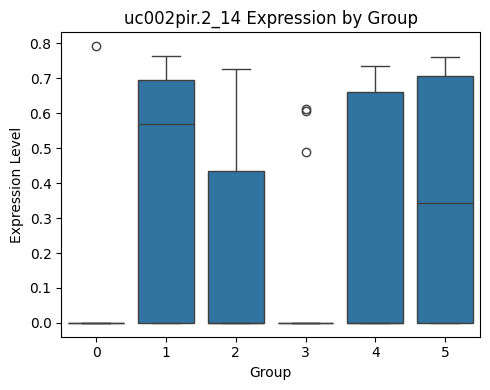

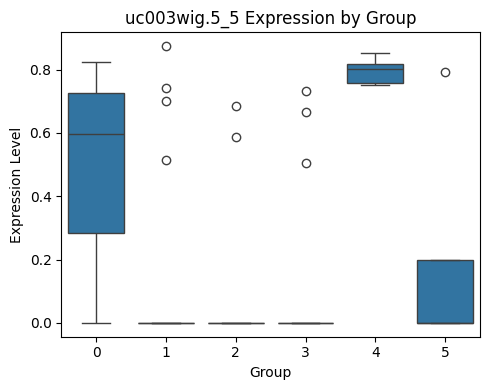

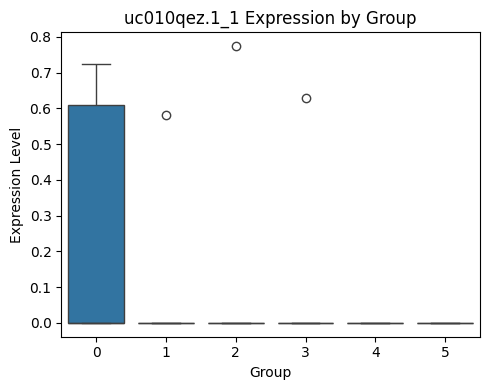

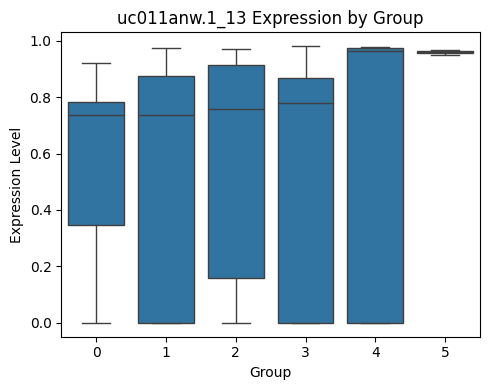

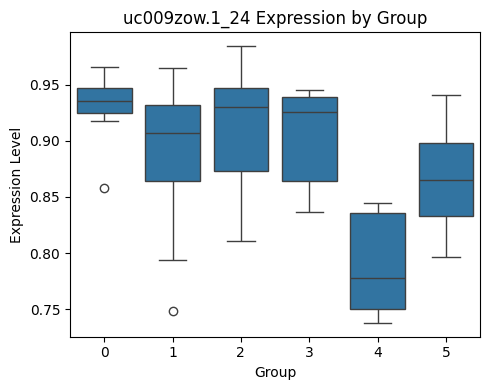

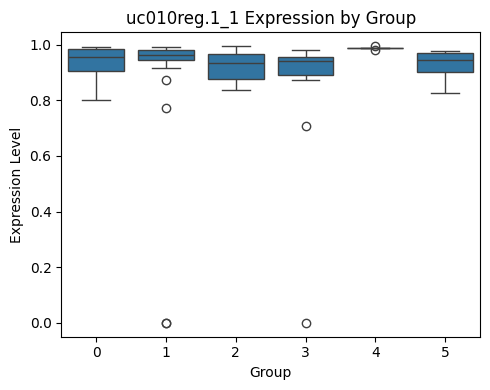

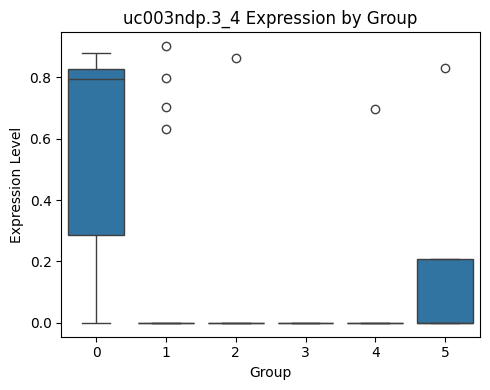

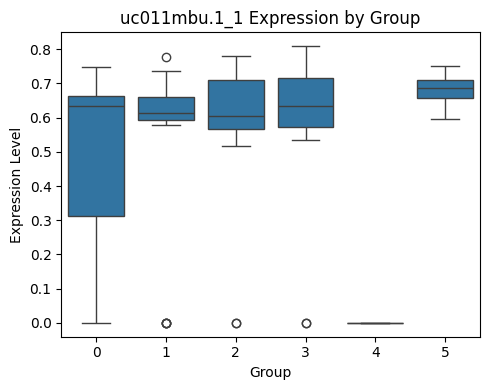

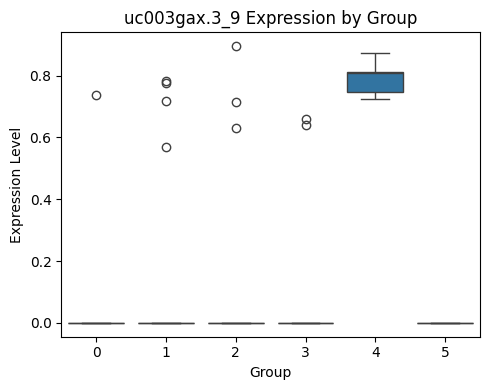

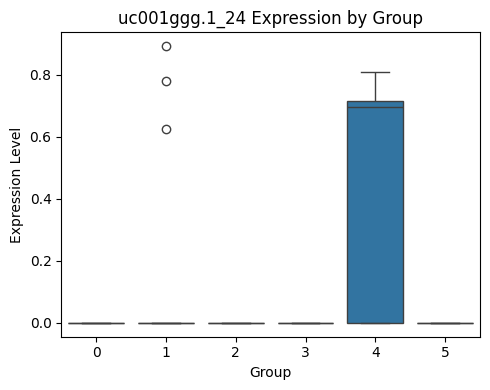

In [ ]:
import seaborn as sns

for gene in status_df["Gene"][:20]:  # Top 5 genes
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=y_orig, y=X_orig[gene])
    plt.title(f"{gene} Expression by Group")
    plt.xlabel("Group")
    plt.ylabel("Expression Level")
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.stats import ttest_ind

p_values = []

for gene in top_gene_ids:
    stat, p = ttest_ind(group_0[gene], others[gene], equal_var=False)
    p_values.append(p)

status_df['p-value'] = p_values
status_df['Significant'] = status_df['p-value'] < 0.05


In [ ]:
# Sort by absolute log2 fold change and print
status_df_sorted = status_df.sort_values(by='Log2FC(Group0 vs Others)', key=abs, ascending=False)

# Display top genes with their significance
print(status_df_sorted[['Gene', 'Log2FC(Group0 vs Others)', 'Status', 'p-value', 'Significant']].to_string(index=False))


         Gene  Log2FC(Group0 vs Others)        Status  p-value  Significant
uc001ggg.1_24                -26.050531 Downregulated 0.013770         True
 uc021ygx.1_1                -24.491851 Downregulated 0.159097        False
 uc010qez.1_1                  3.183631   Upregulated 0.111574        False
 uc003ndp.3_4                  2.737608   Upregulated 0.018493         True
 uc009ynk.3_7                 -1.857442 Downregulated 0.041302         True
 uc003wig.5_5                  1.569499   Upregulated 0.047912         True
uc002pir.2_14                 -1.466432 Downregulated 0.137232        False
uc001xzb.2_13                 -1.458724 Downregulated 0.147018        False
 uc003gax.3_9                 -0.598396 Downregulated 0.642595        False
uc003kek.3_29                 -0.488345 Downregulated 0.181626        False
 uc010jul.1_6                  0.402986   Upregulated 0.537938        False
 uc002pbh.2_3                 -0.357921 Downregulated 0.588175        False
 uc004azi.1_

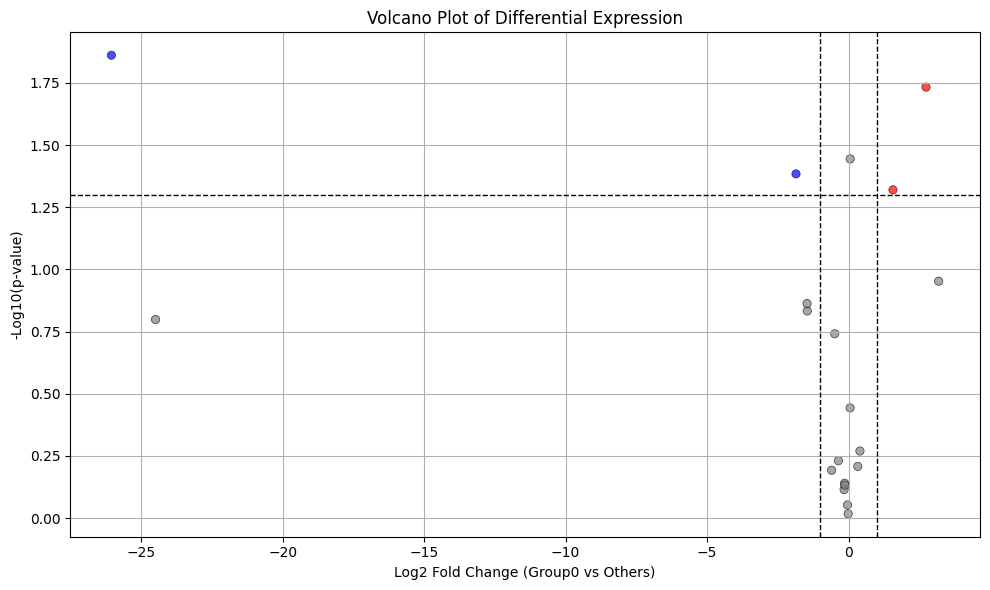

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for volcano plot
status_df['-log10(p-value)'] = -np.log10(status_df['p-value'] + 1e-300)  # Avoid log(0)

# Define significance thresholds
p_threshold = 0.05
fc_threshold = 1  # log2 fold change cutoff

# Color points by significance
def volcano_color(row):
    if row['p-value'] < p_threshold and abs(row['Log2FC(Group0 vs Others)']) > fc_threshold:
        if row['Log2FC(Group0 vs Others)'] > 0:
            return 'red'   # Upregulated & significant
        else:
            return 'blue'  # Downregulated & significant
    else:
        return 'grey'     # Not significant

status_df['color'] = status_df.apply(volcano_color, axis=1)

# Plot volcano plot
plt.figure(figsize=(10, 6))
plt.scatter(status_df['Log2FC(Group0 vs Others)'], status_df['-log10(p-value)'],
            c=status_df['color'], alpha=0.7, edgecolors='k', linewidth=0.5)

# Add horizontal and vertical lines for thresholds
plt.axhline(-np.log10(p_threshold), color='black', linestyle='--', linewidth=1)
plt.axvline(fc_threshold, color='black', linestyle='--', linewidth=1)
plt.axvline(-fc_threshold, color='black', linestyle='--', linewidth=1)

plt.xlabel('Log2 Fold Change (Group0 vs Others)')
plt.ylabel('-Log10(p-value)')
plt.title('Volcano Plot of Differential Expression')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
sig_genes_df = status_df[(status_df['p-value'] < p_threshold) &
                         (status_df['Log2FC(Group0 vs Others)'].abs() > fc_threshold)]

print(f"Number of significant genes: {sig_genes_df.shape[0]}")
print(sig_genes_df[['Gene', 'Log2FC(Group0 vs Others)', 'Status', 'p-value', 'Significant']])


Number of significant genes: 4
             Gene  Log2FC(Group0 vs Others)         Status   p-value  \
0    uc009ynk.3_7                 -1.857442  Downregulated  0.041302   
11   uc003wig.5_5                  1.569499    Upregulated  0.047912   
16   uc003ndp.3_4                  2.737608    Upregulated  0.018493   
19  uc001ggg.1_24                -26.050531  Downregulated  0.013770   

    Significant  
0          True  
11         True  
16         True  
19         True  


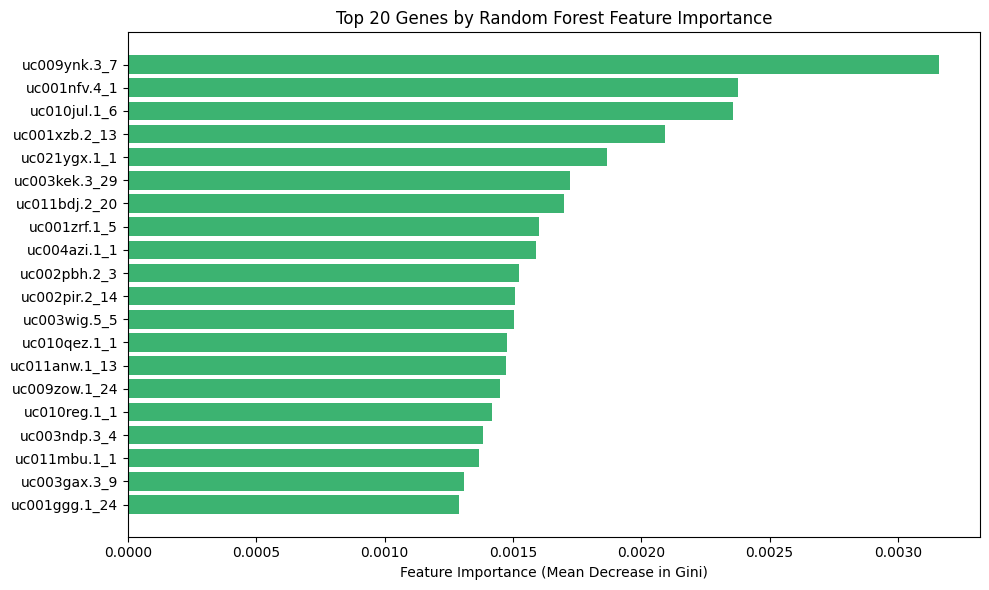


Top 20 Genes (Random Forest Internal Importance):
1. uc009ynk.3_7: 0.00316
2. uc001nfv.4_1: 0.00237
3. uc010jul.1_6: 0.00236
4. uc001xzb.2_13: 0.00209
5. uc021ygx.1_1: 0.00187
6. uc003kek.3_29: 0.00172
7. uc011bdj.2_20: 0.00170
8. uc001zrf.1_5: 0.00160
9. uc004azi.1_1: 0.00159
10. uc002pbh.2_3: 0.00153
11. uc002pir.2_14: 0.00151
12. uc003wig.5_5: 0.00151
13. uc010qez.1_1: 0.00148
14. uc011anw.1_13: 0.00147
15. uc009zow.1_24: 0.00145
16. uc010reg.1_1: 0.00142
17. uc003ndp.3_4: 0.00138
18. uc011mbu.1_1: 0.00137
19. uc003gax.3_9: 0.00131
20. uc001ggg.1_24: 0.00129


In [ ]:
# Get feature importances from trained model
importances = rf.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
top_n = 20
top_indices = indices[:top_n]

# Plot top 20 features
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[top_indices][::-1], color='mediumseagreen')
plt.yticks(ticks=range(top_n), labels=X.columns[top_indices][::-1])
plt.xlabel("Feature Importance (Mean Decrease in Gini)")
plt.title("Top 20 Genes by Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# Print top 20 genes and their importance values
print("\nTop 20 Genes (Random Forest Internal Importance):")
for i in range(top_n):
    gene = X.columns[top_indices[i]]
    importance = importances[top_indices[i]]
    print(f"{i+1}. {gene}: {importance:.5f}")


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the expression data (Excel file)
expr_df = pd.read_excel("/content/drive/MyDrive/GSE65683_ClusterData_PercRank_GEOsubmission.xlsx")

In [ ]:
# Load the annotation data (compressed TSV file)
annot_df = pd.read_csv("/content/drive/MyDrive/Human.GRCh38.p13.annot.tsv.gz", sep='\t')

<ipython-input-3-290e8e7d49a2>:2: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  annot_df = pd.read_csv("/content/drive/MyDrive/Human.GRCh38.p13.annot.tsv.gz", sep='\t')


In [ ]:
print("First 5 rows of the expression data:")
print(expr_df.head())

First 5 rows of the expression data:
    chr  start    end  Element name strand       S25       S52        S3  \
0  chr1  11873  12227  uc001aaa.3_1      +  0.000000  0.487285  0.000000   
1  chr1  12612  12721  uc001aaa.3_2      +  0.000000  0.583267  0.000000   
2  chr1  13220  14409  uc001aaa.3_3      +  0.740841  0.566300  0.759215   
3  chr1  12645  12697  uc010nxr.1_2      +  0.000000  0.662522  0.000000   
4  chr1  12594  12721  uc010nxq.1_2      +  0.000000  0.569954  0.000000   

        S17       S13  ...       S53  S64       S65  S66  S67   H1        H2  \
0  0.000000  0.000000  ...  0.591798  0.0  0.697159  0.0  0.0  0.0  0.000000   
1  0.000000  0.000000  ...  0.000000  0.0  0.000000  0.0  0.0  0.0  0.820517   
2  0.602943  0.764574  ...  0.000000  0.0  0.745730  0.0  0.0  0.0  0.763784   
3  0.000000  0.000000  ...  0.000000  0.0  0.000000  0.0  0.0  0.0  0.000000   
4  0.000000  0.000000  ...  0.000000  0.0  0.000000  0.0  0.0  0.0  0.813277   

         H3        H4    

In [ ]:
print("\nFirst 5 rows of the annotation data:")
print(annot_df.head())


First 5 rows of the annotation data:
      GeneID       Symbol                                 Description  \
0  100287102      DDX11L1  DEAD/H-box helicase 11 like 1 (pseudogene)   
1     653635       WASH7P           WASP family homolog 7, pseudogene   
2  102466751    MIR6859-1                             microRNA 6859-1   
3  107985730  MIR1302-2HG                         MIR1302-2 host gene   
4  100302278    MIR1302-2                             microRNA 1302-2   

                    Synonyms GeneType    EnsemblGeneID  Status        ChrAcc  \
0                        NaN   pseudo  ENSG00000290825  active  NC_000001.11   
1              FAM39F|WASH5P   pseudo              NaN  active  NC_000001.11   
2             hsa-mir-6859-1    ncRNA  ENSG00000278267  active  NC_000001.11   
3                        NaN    ncRNA              NaN  active  NC_000001.11   
4  MIRN1302-2|hsa-mir-1302-2    ncRNA  ENSG00000284332  active  NC_000001.11   

  ChrStart ChrStop Orientation  Length GOF

In [ ]:
# Clean the ChrAcc field to UCSC style
def clean_chr(chracc):
    chr_map = {
        'NC_000023': 'chrX',
        'NC_000024': 'chrY',
        'NC_012920': 'chrM'
    }
    acc = chracc.split('.')[0]
    if acc in chr_map:
        return chr_map[acc]
    else:
        # Ensure we handle potential non-numeric parts if present after split/replace
        num_part = acc.replace('NC_000', '').lstrip('0')
        return 'chr' + (num_part if num_part else '0') # Handle cases where replacement results in empty string


annot_df['chr'] = annot_df['ChrAcc'].apply(clean_chr)

# Ensure coordinate columns are integers
expr_df['start'] = expr_df['start'].astype(int)
expr_df['end'] = expr_df['end'].astype(int)

# --- Fix for ValueError in 'ChrStart' and 'ChrStop' ---
# Define a function to safely convert string coordinates to integer
def safe_int_convert(coord_str):
    if isinstance(coord_str, (int, float)): # Already numeric
        return int(coord_str)
    try:
        # Split by ';' and take the first part, then convert to int
        return int(str(coord_str).split(';')[0])
    except (ValueError, TypeError):
        # If conversion fails, return NaN or handle as appropriate.
        # NaN is useful for later dropping rows or inspection.
        return pd.NA # Use pandas.NA for nullable integer type

annot_df['ChrStart'] = annot_df['ChrStart'].apply(safe_int_convert).astype('Int64') # Use nullable integer
annot_df['ChrStop'] = annot_df['ChrStop'].apply(safe_int_convert).astype('Int64')   # Use nullable integer
# --- End of Fix ---


# Filter to top 20 UCSC Element names
top_elements_manual = [
    "uc009ynk.3_7", "uc001nfv.4_1", "uc010jul.1_6", "uc001xzb.2_13", "uc021ygx.1_1",
    "uc003kek.3_29", "uc011bdj.2_20", "uc001zrf.1_5", "uc004azi.1_1", "uc002pbh.2_3",
    "uc002pir.2_14", "uc003wig.5_5", "uc010qez.1_1", "uc011anw.1_13", "uc009zow.1_24",
    "uc010reg.1_1", "uc003ndp.3_4", "uc011mbu.1_1", "uc003gax.3_9", "uc001ggg.1_24"
]

expr_top = expr_df[expr_df['Element name'].isin(top_elements_manual)].copy()

# Drop rows with missing ChrStart or ChrStop introduced by safe_int_convert
annot_df_cleaned = annot_df.dropna(subset=['ChrStart', 'ChrStop']).copy()

# Merge on 'chr' and filter based on genomic coordinates
# Use the cleaned annotation DataFrame for the merge
merged = pd.merge(expr_top, annot_df_cleaned, on='chr', suffixes=('_expr', '_annot'))


# Keep only rows where transcript is within gene annotation region
# Note: The merge might result in multiple gene annotations for a single transcript if they overlap.
# The current logic keeps all such matches. Depending on the desired outcome,
# you might need to refine this filtering (e.g., keep the closest gene, etc.)
filtered = merged[
    (merged['start'] >= merged['ChrStart']) &
    (merged['end'] <= merged['ChrStop'])
]

# Select relevant output columns
# Ensure uniqueness based on the combination of Element name and Gene annotation info
result_df = filtered[[
    'Element name', 'chr', 'start', 'end', 'strand',
    'GeneID', 'Symbol', 'GeneType', 'EnsemblGeneID', 'Description'
]].drop_duplicates(subset=['Element name', 'GeneID']).sort_values(by='Element name').reset_index(drop=True)

# Display result
print(result_df)

     Element name    chr      start        end strand     GeneID      Symbol  \
0   uc001ggg.1_24   chr1  169551668  169551760      -       2153          F5   
1    uc001nfv.4_1  chr11   47586981   47587538      +     399888     FAM180B   
2   uc001xzb.2_13  chr14   91666100   91666249      +      79820    CATSPERB   
3    uc001zrf.1_5  chr15   43574041   43574284      -       9677     PPIP5K1   
4    uc002pbh.2_3  chr19   45855763   45855907      -       8189       SYMPK   
5   uc002pir.2_14  chr19   48822690   48823332      -      51171    HSD17B14   
6    uc003gax.3_9   chr4     680320     680479      -       4636        MYL5   
7    uc003gax.3_9   chr4     680320     680479      -      84179     SLC49A3   
8   uc003kek.3_29   chr5   75978939   75979042      +      22987        SV2C   
9    uc003ndp.3_4   chr6   22294637   22294813      -       5617         PRL   
10  uc009zow.1_24  chr12   57005556   57006030      -       9880      ZBTB39   
11   uc010jul.1_6   chr6   33144957   33